# Notebook 3 — Patch Pre-computation

**Amaç:** Notebook 2'nin Dataset'i runtime'da ~0.23 sample/sec ile yavaş (Drive I/O bottleneck). Burada **tüm patch'leri bir kere offline çıkarıp** H5 dosyalarına yazıyoruz. Notebook 5'teki training H5'ten okuyacak → 50-100× hız artışı.

**Strateji: scan-level caching.** Aynı seriesuid'in birden fazla sample'ı varsa NPZ tek bir kez yüklenir, tüm patch'leri tek seferde çıkarılır. 888 unique scan, ortalama 8-9 patch/scan → 888 NPZ load ~~> 7700 NPZ load.

**Girdiler:**
- `train_samples.csv`, `val_samples.csv`, `test_samples.csv` (Notebook 2)
- `nodule_masks.h5` (Notebook 1)
- LUNA16 NPZ dosyaları
- `candidates.csv` (genişletilmiş negatif sampling için)

**Çıktılar:**
- `patches_train.h5` — ~3 GB (1100 pos + 5000 neg pool)
- `patches_val.h5`  — ~600 MB
- `patches_test.h5` — ~600 MB

**Storage formatı:** int16 ham HU değerleri (clip/normalize training'de on-the-fly, pretrain ile birebir uyumlu). uint8 binary mask (gzip ile çok sıkışır, çoğu boş).

**Tahmini süre:** ~75-90 dakika (büyük kısmı train).

**Bu notebook tek seferlik.** Pipeline değişmediği sürece tekrar çalıştırmaya gerek yok.


## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time, h5py, json, gc
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import requests

print('Setup OK')

Mounted at /content/drive
Setup OK


## 2. Yollar ve parametreler

In [ ]:
# === GİRDİLER ===
NODULES_CSV    = '/content/drive/MyDrive/bitirme/Finetune_Labels/nodules.csv'
MASKS_H5       = '/content/drive/MyDrive/bitirme/Finetune_Labels/nodule_masks.h5'
CANDIDATES_CSV = '/content/drive/MyDrive/bitirme/Dataset/candidates.csv'
NPZ_DIR        = '/content/drive/MyDrive/bitirme/LUNA_Processed'
SPLIT_META     = '/content/drive/MyDrive/bitirme/Finetune_Labels/splits/split_meta.json'

# === ÇIKTILAR ===
PATCHES_DIR    = '/content/drive/MyDrive/bitirme/Finetune_Patches'
TRAIN_H5       = os.path.join(PATCHES_DIR, 'patches_train.h5')
VAL_H5         = os.path.join(PATCHES_DIR, 'patches_val.h5')
TEST_H5        = os.path.join(PATCHES_DIR, 'patches_test.h5')

os.makedirs(PATCHES_DIR, exist_ok=True)

# === PARAMETRELER ===
PATCH_SIZE = (64, 64, 64)

# Negatif havuz boyutları (her split için)
# Train: ~870 pos × 3 = ~2600 per-epoch; pool 5000 → ~2 epoch fresh
NEG_POOL_SIZE = {
    'train': 5000,
    'val':   1000,
    'test':  1000,
}

RANDOM_SEED = 42

# Telegram notification (opsiyonel, boş bırak istemiyorsan)
TELEGRAM_TOKEN   = '8778723398:AAGS-2c5ddGegnc1ErMf1Lz2RZ_xVSwq3c8'  # 'YOUR_BOT_TOKEN' - pretrain script'inden al
TELEGRAM_CHATID  = '7689600055'  # 'YOUR_CHAT_ID'

print('Konfigürasyon OK')
print(f'Çıktı dizini: {PATCHES_DIR}')

Konfigürasyon OK
Çıktı dizini: /content/drive/MyDrive/bitirme/Finetune_Patches


## 3. Telegram helper (opsiyonel)

In [ ]:
def send_telegram(msg, image_path=None):
    if not TELEGRAM_TOKEN or not TELEGRAM_CHATID:
        return
    try:
        requests.post(
            f'https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage',
            data={'chat_id': TELEGRAM_CHATID, 'text': msg, 'parse_mode': 'Markdown'},
            timeout=15,
        )
        if image_path and os.path.exists(image_path):
            with open(image_path, 'rb') as f:
                requests.post(
                    f'https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendPhoto',
                    data={'chat_id': TELEGRAM_CHATID},
                    files={'photo': f}, timeout=20,
                )
    except Exception as e:
        print(f'Telegram hatası: {e}')

## 4. Notebook 1 + 2 çıktılarını yükle

In [ ]:
# Notebook 1 — pozitif nodüller (kanonik)
nodules_df = pd.read_csv(NODULES_CSV)
print(f'nodules.csv:    {len(nodules_df)} satır')

# Notebook 2 — split metadata
with open(SPLIT_META) as f:
    split_meta = json.load(f)
train_scans = set(split_meta['scans']['train'])
val_scans   = set(split_meta['scans']['val'])
test_scans  = set(split_meta['scans']['test'])
print(f'Scan split:     train={len(train_scans)}, val={len(val_scans)}, test={len(test_scans)}')

# candidates.csv — negatif havuzu için
candidates_df = pd.read_csv(CANDIDATES_CSV)
neg_pool_all = candidates_df[candidates_df['class'] == 0].copy()
print(f'Toplam negatif: {len(neg_pool_all):,}')

# NPZ map
npz_path_map = {}
for p in Path(NPZ_DIR).glob('*.npz'):
    stem = p.stem
    npz_path_map[stem] = p
    npz_path_map[stem.replace('_', '.')] = p
print(f'NPZ map girişi: {len(npz_path_map)}')

nodules.csv:    1100 satır
Scan split:     train=710, val=88, test=90
Toplam negatif: 549,714
NPZ map girişi: 888


## 5. Her split için pozitif + genişletilmiş negatif pool

Notebook 2'deki 1:3 sample listesi yerine, **daha geniş bir negatif havuz** çıkartıyoruz. Training'de bu havuzdan her epoch fresh sample alınır.

In [ ]:
def build_split_samples(split_name, scan_set, neg_count, seed):
    '''Pozitif (tüm) + neg_count rastgele negatif.'''
    # Pozitifler (Notebook 1'in nodules.csv'sinden)
    pos = nodules_df[nodules_df['seriesuid'].isin(scan_set)].copy()
    pos['is_nodule'] = 1

    # Negatifler: bu split'in scan'lerinden random sample
    neg_avail = neg_pool_all[neg_pool_all['seriesuid'].isin(scan_set)]
    if len(neg_avail) < neg_count:
        print(f'  ⚠️ {split_name}: {len(neg_avail)} negatif var, {neg_count} isteniyor')
        neg = neg_avail.copy()
    else:
        neg = neg_avail.sample(n=neg_count, random_state=seed).reset_index(drop=True)
    neg['is_nodule'] = 0

    # Uniform kolonlar
    keep_cols = ['seriesuid', 'coordX', 'coordY', 'coordZ', 'is_nodule',
                 'malignancy_label', 'has_mask', 'mask_key', 'diameter_mm']

    # Negatif'e eksik kolonları NaN olarak ekle
    for c in keep_cols:
        if c not in neg.columns:
            neg[c] = np.nan

    combined = pd.concat([pos[keep_cols], neg[keep_cols]], ignore_index=True)
    return combined


splits = {}
for name, scans, seed_off in [('train', train_scans, 1), ('val', val_scans, 2), ('test', test_scans, 3)]:
    splits[name] = build_split_samples(name, scans, NEG_POOL_SIZE[name], RANDOM_SEED + seed_off)
    n_pos = (splits[name]['is_nodule'] == 1).sum()
    n_neg = (splits[name]['is_nodule'] == 0).sum()
    print(f'{name.upper()}: {n_pos} pos + {n_neg} neg = {len(splits[name])} sample')

TRAIN: 870 pos + 5000 neg = 5870 sample
VAL: 100 pos + 1000 neg = 1100 sample
TEST: 130 pos + 1000 neg = 1130 sample


## 6. Scan-cached patch extractor

Bir scan'in tüm sample'larını gruplar, NPZ'yi bir kere yükler. Her grup için patch + mask çıkartır.

In [ ]:
def world_to_voxel(world_x, world_y, world_z, origin, spacing):
    '''world XYZ → voxel ZYX (NPZ ZYX order).'''
    vz = (world_z - origin[0]) / spacing[0]
    vy = (world_y - origin[1]) / spacing[1]
    vx = (world_x - origin[2]) / spacing[2]
    return int(round(vz)), int(round(vy)), int(round(vx))


def extract_patch(scan, center_zyx, patch_size, pad_value=-1000):
    '''
    Scan'den 64³ patch çek. Kenarda zero-pad (HU=-1000, air).

    Returns: (patch, patch_origin_zyx)
    '''
    pz, py, px = patch_size
    cz, cy, cx = center_zyx

    z0 = cz - pz // 2
    y0 = cy - py // 2
    x0 = cx - px // 2

    # Pad miktarları
    pad_z0 = max(0, -z0); pad_z1 = max(0, (z0 + pz) - scan.shape[0])
    pad_y0 = max(0, -y0); pad_y1 = max(0, (y0 + py) - scan.shape[1])
    pad_x0 = max(0, -x0); pad_x1 = max(0, (x0 + px) - scan.shape[2])

    # Crop alanı
    cz0 = max(0, z0); cz1 = min(scan.shape[0], z0 + pz)
    cy0 = max(0, y0); cy1 = min(scan.shape[1], y0 + py)
    cx0 = max(0, x0); cx1 = min(scan.shape[2], x0 + px)

    crop = scan[cz0:cz1, cy0:cy1, cx0:cx1]

    if any([pad_z0, pad_z1, pad_y0, pad_y1, pad_x0, pad_x1]):
        crop = np.pad(crop,
                      ((pad_z0, pad_z1), (pad_y0, pad_y1), (pad_x0, pad_x1)),
                      mode='constant', constant_values=pad_value)

    patch_origin_zyx = (z0, y0, x0)
    return crop, patch_origin_zyx


def get_mask_for_patch(masks_h5, mask_key, patch_origin_zyx, patch_size):
    '''H5'ten mask çek, sadece patch içine düşen kısmı al.'''
    pz, py, px = patch_size
    patch_mask = np.zeros(patch_size, dtype=np.uint8)

    if mask_key is None or (isinstance(mask_key, float) and pd.isna(mask_key)):
        return patch_mask

    if mask_key not in masks_h5:
        return patch_mask

    grp = masks_h5[mask_key]
    m_full = grp['mask'][:]
    zs, ze = grp.attrs['z_start'], grp.attrs['z_stop']
    ys, ye = grp.attrs['y_start'], grp.attrs['y_stop']
    xs, xe = grp.attrs['x_start'], grp.attrs['x_stop']

    poz, poy, pox = patch_origin_zyx
    pze, pye, pxe = poz + pz, poy + py, pox + px

    ov_zs = max(zs, poz); ov_ze = min(ze, pze)
    ov_ys = max(ys, poy); ov_ye = min(ye, pye)
    ov_xs = max(xs, pox); ov_xe = min(xe, pxe)

    if ov_ze <= ov_zs or ov_ye <= ov_ys or ov_xe <= ov_xs:
        return patch_mask

    patch_mask[ov_zs-poz:ov_ze-poz, ov_ys-poy:ov_ye-poy, ov_xs-pox:ov_xe-pox] = \
        m_full[ov_zs-zs:ov_ze-zs, ov_ys-ys:ov_ye-ys, ov_xs-xs:ov_xe-xs]

    return patch_mask


print('Helper fonksiyonlar tanımlandı ✅')

Helper fonksiyonlar tanımlandı ✅


## 7. Drive resilience helper

Pre-computation uzun süreceği için Drive bağlantısı kopabilir. Auto-remount mantığı.

In [ ]:
from google.colab import drive as gdrive

def ensure_drive():
    try:
        os.listdir('/content/drive/MyDrive')
        return True
    except OSError:
        print('  ⚠️ Drive kopması, remount...')
        try:
            gdrive.mount('/content/drive', force_remount=True)
            time.sleep(3)
            return True
        except Exception as e:
            print(f'  ❌ Remount fail: {e}')
            return False


def safe_npz_load(path, max_retries=3):
    '''Drive I/O hatasına dirençli NPZ load.'''
    for attempt in range(max_retries):
        try:
            return np.load(path)
        except OSError as e:
            if e.errno in (5, 107):
                if attempt < max_retries - 1:
                    ensure_drive()
                    time.sleep(2 ** attempt)
                    continue
            raise
        except Exception:
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
            raise
    return None

## 8. Ana pre-compute fonksiyonu

Bir split için tüm patch'leri scan-cached olarak H5'e yazar.

In [ ]:
def precompute_split(samples_df, out_h5_path, split_name):
    '''
    samples_df'deki tüm patch'leri scan-cached olarak çıkar, H5'e yaz.

    H5 yapısı:
      patches      uint16 (N, 64, 64, 64)   ← int16 değerleri uint16 olarak (HU+offset gerekiyor)
      ↑ aslında int16 saklayacağız, h5py int16 destekler
      masks        uint8  (N, 64, 64, 64)
      detection    uint8  (N,)
      malignancy   int8   (N,)   ← -1 olabildiği için signed
      seg_loss_mask uint8 (N,)
      seriesuids   variable-length str (N,)
      world_coords float32 (N, 3)  ← debug için
      attrs:
        patch_size, hu_pad_value, n_samples, created_at, split_name
    '''
    N = len(samples_df)
    pz, py, px = PATCH_SIZE

    print(f'\n{"="*60}')
    print(f'PRE-COMPUTE: {split_name.upper()} → {out_h5_path}')
    print(f'{"="*60}')
    print(f'  Sample sayısı: {N}')

    # Scan grupla — tek NPZ load ile tüm sample'larını çıkar
    samples_df = samples_df.reset_index(drop=True)
    by_scan = defaultdict(list)
    for idx in range(N):
        sid = samples_df.iloc[idx]['seriesuid']
        by_scan[sid].append(idx)

    print(f'  Unique scan: {len(by_scan)}')
    print(f'  Ortalama sample/scan: {N/len(by_scan):.1f}')

    # H5 oluştur
    if os.path.exists(out_h5_path):
        os.remove(out_h5_path)

    # Buffered write için RAM'de batch tutma — tek geçişte yazmak için
    # H5'leri büyütülebilir mode'da aç (resize ile büyüt)
    h5 = h5py.File(out_h5_path, 'w')

    # Chunk size (1, 64, 64, 64) → tek sample erişimi optimal
    chunks_patch = (1, pz, py, px)
    chunks_mask = (1, pz, py, px)

    h5.create_dataset('patches', shape=(N, pz, py, px), dtype='i2',
                      chunks=chunks_patch, compression='gzip', compression_opts=4)
    h5.create_dataset('masks', shape=(N, pz, py, px), dtype='u1',
                      chunks=chunks_mask, compression='gzip', compression_opts=4)
    h5.create_dataset('detection', shape=(N,), dtype='u1')
    h5.create_dataset('malignancy', shape=(N,), dtype='i1')
    h5.create_dataset('seg_loss_mask', shape=(N,), dtype='u1')
    h5.create_dataset('world_coords', shape=(N, 3), dtype='f4')
    dt_str = h5py.string_dtype(encoding='utf-8')
    h5.create_dataset('seriesuids', shape=(N,), dtype=dt_str)

    h5.attrs['patch_size'] = list(PATCH_SIZE)
    h5.attrs['hu_pad_value'] = -1000
    h5.attrs['split_name'] = split_name
    h5.attrs['note'] = 'patches are int16 raw HU; normalize/clip at training time'
    h5.attrs['created_at'] = time.strftime('%Y-%m-%d %H:%M:%S')

    # Mask H5'i aç (read-only, persistent)
    masks_h5 = h5py.File(MASKS_H5, 'r')

    n_written = 0
    n_failed = 0
    n_npz_missing = 0
    t_start = time.time()

    # Per-scan iteration
    scan_pbar = tqdm(by_scan.items(), desc=f'{split_name} scans', total=len(by_scan))
    for seriesuid, idx_list in scan_pbar:
        npz_path = npz_path_map.get(seriesuid)
        if npz_path is None:
            n_npz_missing += len(idx_list)
            # Bu scan'in tüm sample'larını skip et — zeros yazalım ki indeks tutarlı kalsın
            for idx in idx_list:
                h5['patches'][idx] = -1000  # full air patch (zaten zero kabul edilir)
                h5['masks'][idx] = 0
                # Label'lar yine yazılsın (training'de filter edilebilir)
                row = samples_df.iloc[idx]
                h5['detection'][idx] = int(row['is_nodule'])
                ml = row.get('malignancy_label')
                h5['malignancy'][idx] = -1 if pd.isna(ml) else int(ml)
                h5['seg_loss_mask'][idx] = 0
                h5['seriesuids'][idx] = seriesuid
                h5['world_coords'][idx] = [row['coordX'], row['coordY'], row['coordZ']]
            continue

        # NPZ yükle (drive-resilient)
        try:
            data = safe_npz_load(npz_path)
            scan = data['scan']
            origin = data['origin']
            spacing = data['spacing']
        except Exception as e:
            print(f'  ⚠️ NPZ load fail [{seriesuid[:30]}...]: {e}')
            n_failed += len(idx_list)
            continue

        # Bu scan'deki tüm sample'ları işle
        for idx in idx_list:
            row = samples_df.iloc[idx]
            try:
                vz, vy, vx = world_to_voxel(row['coordX'], row['coordY'], row['coordZ'],
                                              origin, spacing)
                patch, patch_origin = extract_patch(scan, (vz, vy, vx), PATCH_SIZE)

                # int16 olarak yaz (ham HU)
                patch_i16 = patch.astype(np.int16)
                h5['patches'][idx] = patch_i16

                # Mask
                is_nodule = int(row['is_nodule'])
                if is_nodule == 1:
                    mask_key = row.get('mask_key')
                    mask = get_mask_for_patch(masks_h5, mask_key, patch_origin, PATCH_SIZE)
                    seg_loss_mask = 1 if (mask_key and not pd.isna(mask_key)) else 0
                else:
                    mask = np.zeros(PATCH_SIZE, dtype=np.uint8)
                    seg_loss_mask = 0

                h5['masks'][idx] = mask
                h5['detection'][idx] = is_nodule
                h5['seg_loss_mask'][idx] = seg_loss_mask

                # Malignancy
                ml = row.get('malignancy_label')
                h5['malignancy'][idx] = -1 if pd.isna(ml) else int(ml)

                # Metadata
                h5['seriesuids'][idx] = seriesuid
                h5['world_coords'][idx] = [row['coordX'], row['coordY'], row['coordZ']]

                n_written += 1

            except Exception as e:
                print(f'  ⚠️ Sample [{idx}] fail: {e}')
                n_failed += 1
                h5['patches'][idx] = -1000
                h5['masks'][idx] = 0
                continue

        del scan, data
        # Drive baskısını azalt
        if len(idx_list) > 5:
            gc.collect()

    masks_h5.close()

    elapsed = time.time() - t_start
    file_size_mb = os.path.getsize(out_h5_path) / (1024*1024)

    h5.attrs['n_written'] = n_written
    h5.attrs['n_failed'] = n_failed
    h5.attrs['n_npz_missing'] = n_npz_missing
    h5.attrs['elapsed_sec'] = elapsed
    h5.close()

    print(f'\n  ✅ Tamamlandı: {n_written}/{N}')
    print(f'     Başarısız:   {n_failed}')
    print(f'     NPZ eksik:   {n_npz_missing}')
    print(f'     Süre:        {elapsed/60:.1f} dakika')
    print(f'     Dosya boyutu: {file_size_mb:.0f} MB')

    return n_written, n_failed

## 9. Train pre-compute (en uzun, ~45-60 dakika)

Devam ederken Telegram aktifse epoch sonu bildirimi alırsın.

In [ ]:
# Drive remount + timeout'lu NPZ loader + train pre-compute (tek hücre)

from google.colab import drive as gdrive
import signal

gdrive.mount('/content/drive', force_remount=True)

def _timeout_handler(signum, frame):
    raise OSError(107, 'NPZ load timeout')

def safe_npz_load(path, timeout_sec=25, max_retries=3):
    '''Timeout'lu NPZ loader — Drive stall'larında remount tetikler.'''
    for attempt in range(max_retries):
        try:
            signal.signal(signal.SIGALRM, _timeout_handler)
            signal.alarm(timeout_sec)
            data = np.load(path)
            signal.alarm(0)
            return data
        except OSError as e:
            signal.alarm(0)
            if attempt < max_retries - 1:
                print(f'  ⚠️ NPZ load fail (attempt {attempt+1}): {e}')
                ensure_drive()
                time.sleep(2 ** attempt)
            else:
                raise
    raise IOError(f'NPZ yüklenemedi: {path}')

# --- Train pre-compute ---
send_telegram(f'🚀 *Patch pre-computation başladı*\n\nTrain: {len(splits["train"])} sample')

t0 = time.time()
n_ok_train, n_fail_train = precompute_split(splits['train'], TRAIN_H5, 'train')
train_elapsed = time.time() - t0

send_telegram(
    f'✅ *Train pre-compute bitti*\n\n'
    f'Yazılan: {n_ok_train}\n'
    f'Süre: {train_elapsed/60:.1f} dk\n'
    f'Dosya: {os.path.getsize(TRAIN_H5)/(1024*1024):.0f} MB'
)

Mounted at /content/drive

PRE-COMPUTE: TRAIN → /content/drive/MyDrive/bitirme/Finetune_Patches/patches_train.h5
  Sample sayısı: 5870
  Unique scan: 707
  Ortalama sample/scan: 8.3


train scans:   0%|          | 0/707 [00:00<?, ?it/s]

  ⚠️ Sample [964] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [1656] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [2810] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [3080] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [3409] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [3554] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [4016] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [4027] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [4206] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [4327] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [4491] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [1044] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [1405] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [1569] fail: Can't broadcast (64, 576, 576) -> (64, 6

## 10. Val pre-compute (~10 dakika)

In [ ]:
t0 = time.time()
n_ok_val, n_fail_val = precompute_split(splits['val'], VAL_H5, 'val')
val_elapsed = time.time() - t0

send_telegram(
    f'✅ *Val pre-compute bitti*\n\n'
    f'Yazılan: {n_ok_val}\n'
    f'Süre: {val_elapsed/60:.1f} dk\n'
    f'Dosya: {os.path.getsize(VAL_H5)/(1024*1024):.0f} MB'
)


PRE-COMPUTE: VAL → /content/drive/MyDrive/bitirme/Finetune_Patches/patches_val.h5
  Sample sayısı: 1100
  Unique scan: 88
  Ortalama sample/scan: 12.5


val scans:   0%|          | 0/88 [00:00<?, ?it/s]

  ⚠️ Sample [257] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [266] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [268] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [466] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [533] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [619] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [720] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [1032] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)
  ⚠️ Sample [1041] fail: Can't broadcast (64, 576, 576) -> (64, 64, 64)

  ✅ Tamamlandı: 1091/1100
     Başarısız:   9
     NPZ eksik:   0
     Süre:        9.7 dakika
     Dosya boyutu: 374 MB


## 11. Test pre-compute (~10 dakika)

In [ ]:
t0 = time.time()
n_ok_test, n_fail_test = precompute_split(splits['test'], TEST_H5, 'test')
test_elapsed = time.time() - t0

send_telegram(
    f'✅ *Test pre-compute bitti*\n\n'
    f'Yazılan: {n_ok_test}\n'
    f'Süre: {test_elapsed/60:.1f} dk\n'
    f'Dosya: {os.path.getsize(TEST_H5)/(1024*1024):.0f} MB'
)


PRE-COMPUTE: TEST → /content/drive/MyDrive/bitirme/Finetune_Patches/patches_test.h5
  Sample sayısı: 1130
  Unique scan: 90
  Ortalama sample/scan: 12.6


test scans:   0%|          | 0/90 [00:00<?, ?it/s]


  ✅ Tamamlandı: 1130/1130
     Başarısız:   0
     NPZ eksik:   0
     Süre:        11.2 dakika
     Dosya boyutu: 379 MB


## 12. Sanity check — H5'ten geri oku, görselleştir

Mask hâlâ nodüle biniyor mu, value range doğru mu?

--- TRAIN H5 ---
Pozitif örnek:
  Index 616: 1.3.6.1.4.1.14519.5.2.1.6279.6001.3...
    detection=1, malignancy=1, seg_loss_mask=1
    World coord: (-46.2, 14.9, -198.5)
    Patch dtype=int16, range=[-1024, 3071], shape=(64, 64, 64)
    Mask voxel count: 527


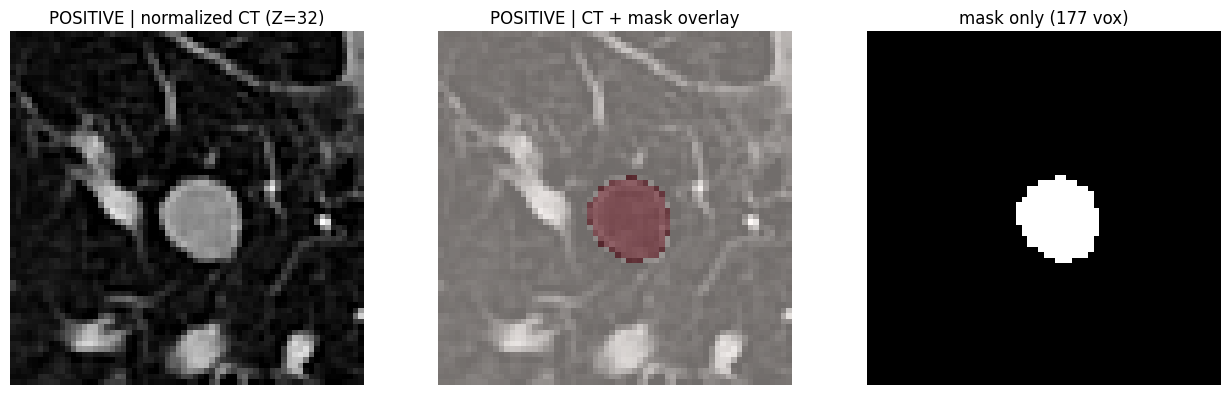

Negatif örnek:
  Index 3663: 1.3.6.1.4.1.14519.5.2.1.6279.6001.2...
    detection=0, malignancy=-1, seg_loss_mask=0
    World coord: (142.9, 24.9, -281.2)
    Patch dtype=int16, range=[-1024, 2017], shape=(64, 64, 64)
    Mask voxel count: 0


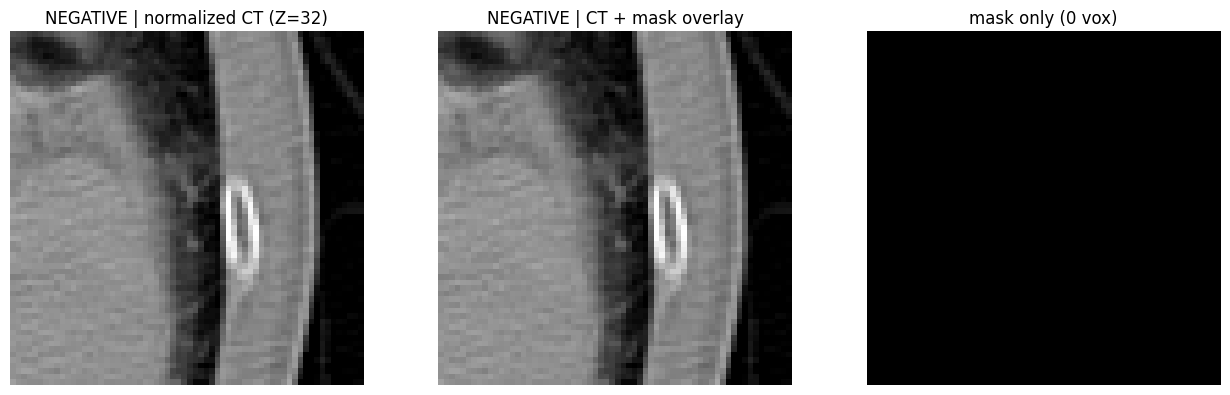

In [ ]:
def visualize_h5_sample(h5_path, sample_type='positive'):
    with h5py.File(h5_path, 'r') as h5:
        N = h5['patches'].shape[0]
        det = h5['detection'][:]
        mal = h5['malignancy'][:]
        seg = h5['seg_loss_mask'][:]

        # Pozitif + malign + mask'li bir örnek seç
        if sample_type == 'positive':
            candidates = np.where((det == 1) & (mal == 1) & (seg == 1))[0]
            if len(candidates) == 0:
                candidates = np.where((det == 1) & (seg == 1))[0]
        else:
            candidates = np.where(det == 0)[0]

        if len(candidates) == 0:
            print(f'  Uygun {sample_type} sample bulunamadı')
            return

        idx = np.random.choice(candidates)
        patch = h5['patches'][idx]
        mask = h5['masks'][idx]
        seriesuid = h5['seriesuids'][idx]
        if isinstance(seriesuid, bytes):
            seriesuid = seriesuid.decode()
        coord = h5['world_coords'][idx]

        print(f'  Index {idx}: {seriesuid[:35]}...')
        print(f'    detection={det[idx]}, malignancy={mal[idx]}, seg_loss_mask={seg[idx]}')
        print(f'    World coord: ({coord[0]:.1f}, {coord[1]:.1f}, {coord[2]:.1f})')
        print(f'    Patch dtype={patch.dtype}, range=[{patch.min()}, {patch.max()}], shape={patch.shape}')
        print(f'    Mask voxel count: {int(mask.sum())}')

        # Normalize (training'de yapılan adım)
        patch_norm = np.clip(patch, -1000, 1000).astype(np.float32)
        patch_norm = (patch_norm + 1000) / 2000

        z_mid = PATCH_SIZE[0] // 2
        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        axes[0].imshow(patch_norm[z_mid], cmap='gray', vmin=0, vmax=1)
        axes[0].set_title(f'{sample_type.upper()} | normalized CT (Z={z_mid})')
        axes[0].axis('off')

        axes[1].imshow(patch_norm[z_mid], cmap='gray', vmin=0, vmax=1)
        if mask.sum() > 0:
            axes[1].imshow(mask[z_mid], cmap='Reds', alpha=0.45)
        axes[1].set_title(f'{sample_type.upper()} | CT + mask overlay')
        axes[1].axis('off')

        axes[2].imshow(mask[z_mid], cmap='gray')
        axes[2].set_title(f'mask only ({int(mask[z_mid].sum())} vox)')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()


print('--- TRAIN H5 ---')
print('Pozitif örnek:')
visualize_h5_sample(TRAIN_H5, 'positive')
print('Negatif örnek:')
visualize_h5_sample(TRAIN_H5, 'negative')

## 13. H5 okuma hızı testi

NPZ'den 0.23 sample/sec idi. H5'ten ne kadar?

In [ ]:
print('Speed test: H5\'ten 100 random sample okuma...')

import random
with h5py.File(TRAIN_H5, 'r') as h5:
    N = h5['patches'].shape[0]
    indices = random.sample(range(N), min(100, N))

    t0 = time.time()
    for idx in indices:
        patch = h5['patches'][idx]
        mask = h5['masks'][idx]
        det = h5['detection'][idx]
        mal = h5['malignancy'][idx]
        seg = h5['seg_loss_mask'][idx]
    dt = time.time() - t0

rate = len(indices) / dt
print(f'  {len(indices)} sample / {dt:.2f}s = {rate:.1f} sample/sec')
print(f'\nNPZ\'den hız: 0.23 sample/sec')
print(f'H5\'ten hız:  {rate:.1f} sample/sec')
print(f'Speedup:      {rate/0.23:.0f}×')

print(f'\nEpoch süresi tahmini:')
for name, ds_size in [('train', n_ok_train), ('val', n_ok_val)]:
    eta = ds_size / rate
    print(f'  {name}: {ds_size} sample → {eta:.1f} sec ({eta/60:.1f} dk) single-worker')
    print(f'         num_workers=4 ile ~{eta/4:.1f} sec ({eta/60/4:.1f} dk)')

Speed test: H5'ten 100 random sample okuma...
  100 sample / 70.44s = 1.4 sample/sec

NPZ'den hız: 0.23 sample/sec
H5'ten hız:  1.4 sample/sec
Speedup:      6×

Epoch süresi tahmini:
  train: 5796 sample → 4082.7 sec (68.0 dk) single-worker
         num_workers=4 ile ~1020.7 sec (17.0 dk)
  val: 1091 sample → 768.5 sec (12.8 dk) single-worker
         num_workers=4 ile ~192.1 sec (3.2 dk)


## 14. Özet

In [ ]:
total_time = train_elapsed + val_elapsed + test_elapsed
total_size_mb = sum(os.path.getsize(p) for p in [TRAIN_H5, VAL_H5, TEST_H5]) / (1024*1024)

summary = f'''
============================================================
NOTEBOOK 3 — PATCH PRE-COMPUTATION ÖZET
============================================================

⏱️  Toplam süre: {total_time/60:.1f} dakika
💾 Toplam boyut: {total_size_mb:.0f} MB

📂 Çıktı dosyalar:
  Train:  {TRAIN_H5}
          {os.path.getsize(TRAIN_H5)/(1024*1024):.0f} MB, {n_ok_train} sample
  Val:    {VAL_H5}
          {os.path.getsize(VAL_H5)/(1024*1024):.0f} MB, {n_ok_val} sample
  Test:   {TEST_H5}
          {os.path.getsize(TEST_H5)/(1024*1024):.0f} MB, {n_ok_test} sample

📊 Hız:
  Eski NPZ pipeline:  0.23 sample/sec
  Yeni H5 pipeline:   {rate:.1f} sample/sec ({rate/0.23:.0f}× hızlı)

🎯 Sıradaki: Notebook 4 — Multi-task model mimarisi
'''
print(summary)
send_telegram(summary.replace('=', '-'))


NOTEBOOK 3 — PATCH PRE-COMPUTATION ÖZET

⏱️  Toplam süre: 96.3 dakika
💾 Toplam boyut: 2718 MB

📂 Çıktı dosyalar:
  Train:  /content/drive/MyDrive/bitirme/Finetune_Patches/patches_train.h5
          1966 MB, 5796 sample
  Val:    /content/drive/MyDrive/bitirme/Finetune_Patches/patches_val.h5
          374 MB, 1091 sample
  Test:   /content/drive/MyDrive/bitirme/Finetune_Patches/patches_test.h5
          379 MB, 1130 sample

📊 Hız:
  Eski NPZ pipeline:  0.23 sample/sec
  Yeni H5 pipeline:   1.4 sample/sec (6× hızlı)

🎯 Sıradaki: Notebook 4 — Multi-task model mimarisi

